In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv('/Users/loohanweiaugustine/Desktop/Final Coursework IDTA/Submission/Csv Files..../Census.csv')

In [3]:
df_regression = df.copy()

In [4]:
df_regression['No of hours'] = pd.to_numeric(df_regression['No of hours'], errors='coerce')
df_regression['No of hours'] = df_regression['No of hours'].replace(-9, np.nan)

In [5]:
df_regression = df_regression.dropna(subset=['No of hours']).copy()

In [6]:
target_regression = 'No of hours'
y_reg = df_regression[target_regression]
features_to_drop = [target_regression, 'Person ID', 'Hours worked per week']
X_reg = df_regression.drop(columns=features_to_drop)

In [7]:
categorical_features_reg = X_reg.select_dtypes(include=['int64', 'object']).columns

In [8]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_reg)
    ],
    remainder='passthrough'
)

In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=23)

In [10]:
print("\nLinear Regression")
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])

pipeline_lr.fit(X_train_reg, y_train_reg)
y_pred_lr_reg = pipeline_lr.predict(X_test_reg)

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_reg, y_pred_lr_reg))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_lr_reg))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)))
print("R-squared (R²):", r2_score(y_test_reg, y_pred_lr_reg))


Linear Regression
Mean Absolute Error (MAE): 9.266580099222809
Mean Squared Error (MSE): 138.00459423963412
Root Mean Squared Error (RMSE): 11.747535666667886
R-squared (R²): 0.2502625710149442


In [11]:
print("\nRandom Forest Regressor")
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(random_state=23))
])

param_grid_rf_reg = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [5]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf_reg, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_reg, y_train_reg)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_reg)

print("Best Parameters:", grid_rf.best_params_)
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_reg, y_pred_rf))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_rf))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R-squared (R²):", r2_score(y_test_reg, y_pred_rf))


Random Forest Regressor


Exception ignored in: <function ResourceTracker.__del__ at 0x103761bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108061bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1086e5bc0>
Traceback (most recent call last

Best Parameters: {'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}
Mean Absolute Error (MAE): 8.87839145308081
Mean Squared Error (MSE): 129.56136724429015
Root Mean Squared Error (RMSE): 11.382502679300812
R-squared (R²): 0.2961320823504473


In [12]:
results = {
    'Model': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R-squared': []
}

def extract_metrics(model_name, y_test, y_pred):
    results['Model'].append(model_name)
    results['MAE'].append(mean_absolute_error(y_test, y_pred))
    results['MSE'].append(mean_squared_error(y_test, y_pred))
    results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
    results['R-squared'].append(r2_score(y_test, y_pred))

extract_metrics('Linear Regression', y_test_reg, y_pred_lr_reg)
extract_metrics('Random Forest Regressor', y_test_reg, y_pred_rf)

results_reg_df = pd.DataFrame(results)

print("\n--- Final Regression Model Comparison ---")
print(results_reg_df.to_markdown(index=False))


--- Final Regression Model Comparison ---
| Model                   |     MAE |     MSE |    RMSE |   R-squared |
|:------------------------|--------:|--------:|--------:|------------:|
| Linear Regression       | 9.26658 | 138.005 | 11.7475 |    0.250263 |
| Random Forest Regressor | 8.87839 | 129.561 | 11.3825 |    0.296132 |



--- Top 10 Features (Random Forest) ---
| feature                     |   importance |
|:----------------------------|-------------:|
| Approximated Social Grade_4 |    0.0885623 |
| Sex_1                       |    0.0843374 |
| Sex_2                       |    0.0807398 |
| Economic Activity_4         |    0.0493443 |
| Student_2                   |    0.0461382 |
| Student_1                   |    0.0442899 |
| Marital Status_1            |    0.0238912 |
| Age_7                       |    0.0229701 |
| Age_2                       |    0.01955   |
| Industry_10                 |    0.0177853 |


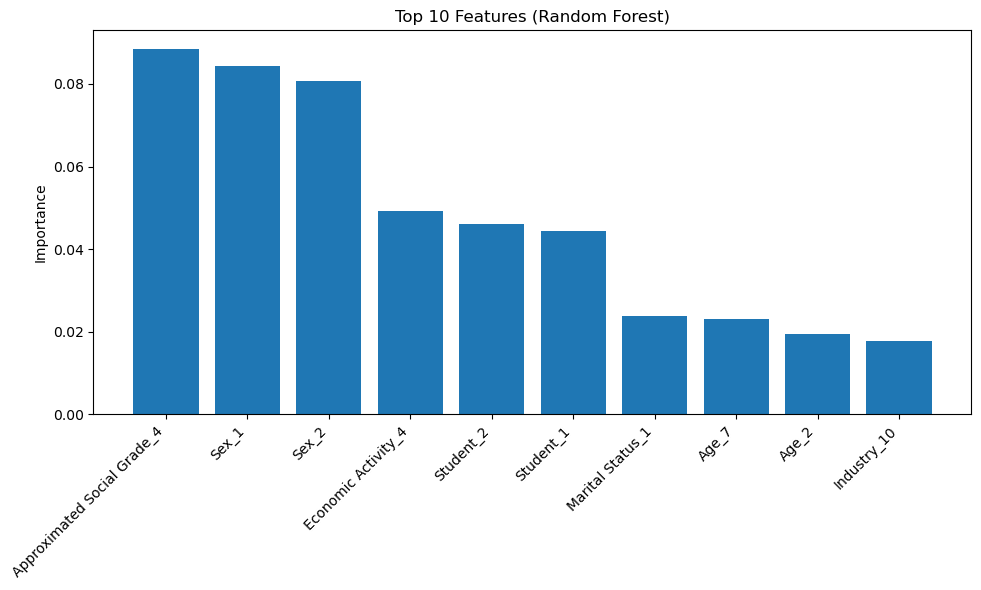

In [13]:
preproc = best_rf.named_steps['preprocessor']
feature_names = preproc.get_feature_names_out(X_train_reg.columns)

rf = best_rf.named_steps['regressor']
importances = rf.feature_importances_

imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

imp_df['feature'] = imp_df['feature'].str.replace(r'^(cat|remainder)__', '', regex=True)

top10_imp = imp_df.head(10)

print("\n--- Top 10 Features (Random Forest) ---")
print(top10_imp.to_markdown(index=False))

plt.figure(figsize=(10, 6))
plt.bar(top10_imp['feature'], top10_imp['importance'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Top 10 Features (Random Forest)')
plt.tight_layout()
plt.show()


--- Top 10 Features (Linear Regression, |coef|) ---
| feature                     |     coef |
|:----------------------------|---------:|
| Industry_1                  |  6.29424 |
| Age_8                       | -5.97868 |
| Age_7                       | -5.93907 |
| Student_2                   |  5.10977 |
| Economic Activity_4         | -5.10977 |
| Student_1                   | -5.10977 |
| Approximated Social Grade_4 | -4.49361 |
| Occupation_8                |  4.00358 |
| Approximated Social Grade_1 |  3.64319 |
| Residence Type_C            |  3.38695 |


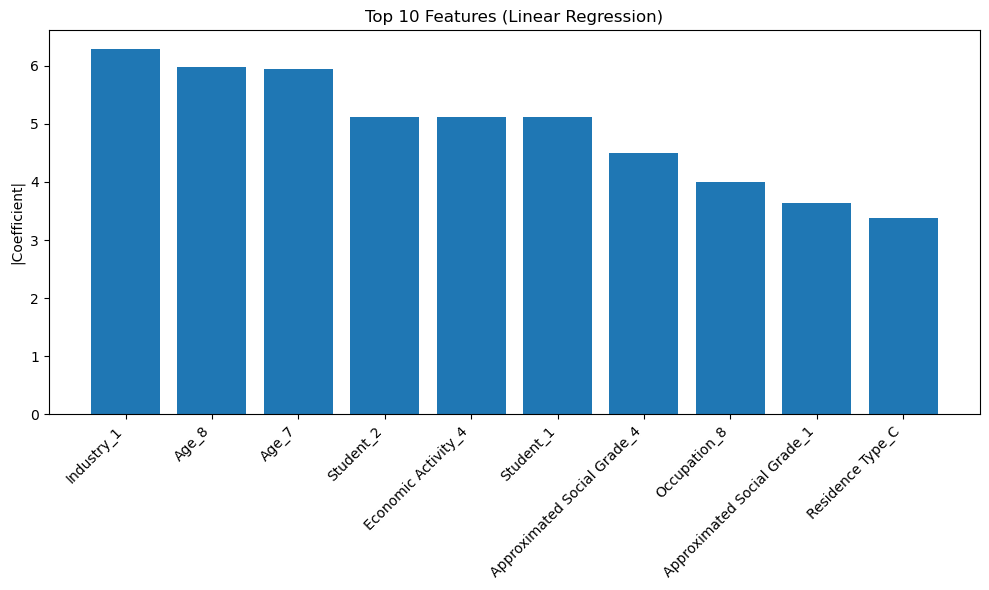

In [14]:
lin = pipeline_lr.named_steps['regressor']
preproc_lr = pipeline_lr.named_steps['preprocessor']
lr_feature_names = preproc_lr.get_feature_names_out(X_train_reg.columns)
lr_coefs = lin.coef_

lr_df = (
    pd.DataFrame({'feature': lr_feature_names, 'coef': lr_coefs, 'abs_coef': np.abs(lr_coefs)})
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)
lr_df['feature'] = lr_df['feature'].str.replace(r'^(cat|remainder)__', '', regex=True)

top10_lr = lr_df.head(10)

print("\n--- Top 10 Features (Linear Regression, |coef|) ---")
print(top10_lr[['feature', 'coef']].to_markdown(index=False))

plt.figure(figsize=(10, 6))
plt.bar(top10_lr['feature'], top10_lr['abs_coef'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('|Coefficient|')
plt.title('Top 10 Features (Linear Regression)')
plt.tight_layout()
plt.show()